In [ ]:
<a href="https://0ghosto.github.io/MIRNoteByAndrew/" style="display:inline-flex;align-items:center;gap:6px;text-decoration:none;font-family:'Inter',sans-serif;font-size:0.82rem;font-weight:500;color:#c96442;background:#fef6f2;border:1px solid #f0d4c8;border-radius:8px;padding:6px 12px;margin-bottom:8px;">&#8592; Home</a>

# Basic Feature Extraction

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy
import sklearn

from mirdotcom import mirdotcom

mirdotcom.init()

In [21]:
import urllib.request

base_url = "https://raw.githubusercontent.com/musicinformationretrieval/musicinformationretrieval.com/gh-pages/mirdotcom/assets/audio/drum_samples/train"
sample_dir = Path("drum_samples/train")
sample_dir.mkdir(parents=True, exist_ok=True)

for drum_name in ["kick", "snare"]:
    for i in range(1, 11):
        filename = f"{drum_name}_{i:02d}.mp3"
        fp = sample_dir / filename
        if not fp.exists():
            urllib.request.urlretrieve(f"{base_url}/{filename}", fp)

kick_signals = [librosa.load(p)[0] for p in sorted(sample_dir.glob("kick_*.mp3"))]
snare_signals = [librosa.load(p)[0] for p in sorted(sample_dir.glob("snare_*.mp3"))]

In [22]:
len(kick_signals)

10

In [23]:
len(snare_signals)

10

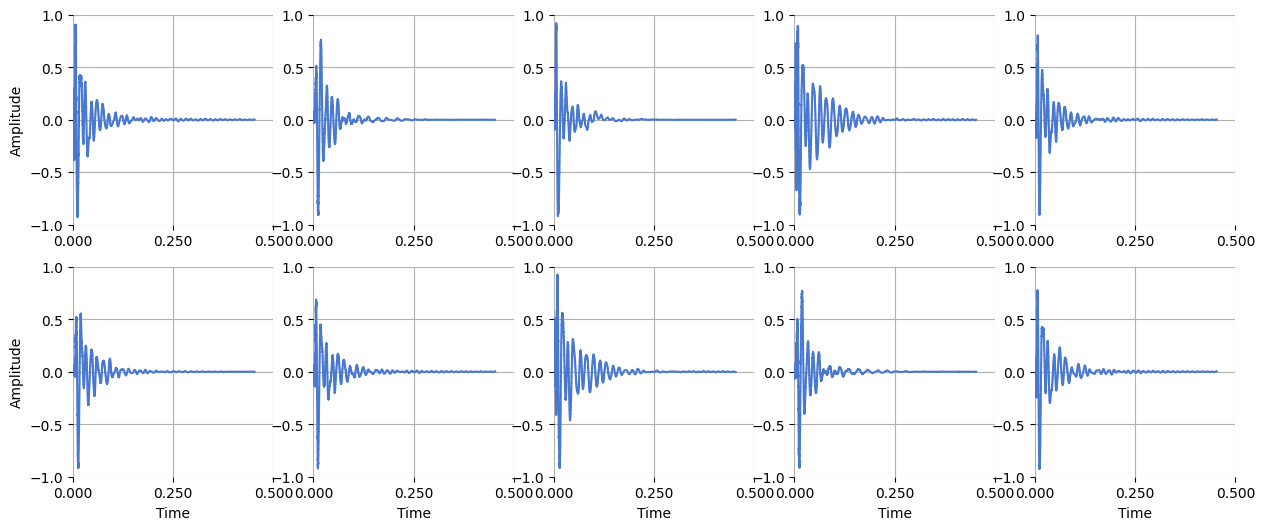

In [24]:
plt.figure(figsize=(15, 6))
for i, x in enumerate(kick_signals):
    plt.subplot(2, 5, i + 1)
    librosa.display.waveshow(x[:10000])

    # Y-axis label only on the first column
    if i == 0 or i == 5:
        plt.ylabel("Amplitude")

    # X-axis label only on the bottom row
    if i >= 5:
        plt.xlabel("Time")
    else:
        plt.xlabel("")

    plt.gca().set_xticks([0, 0.25, 0.5])
    plt.ylim(-1, 1)

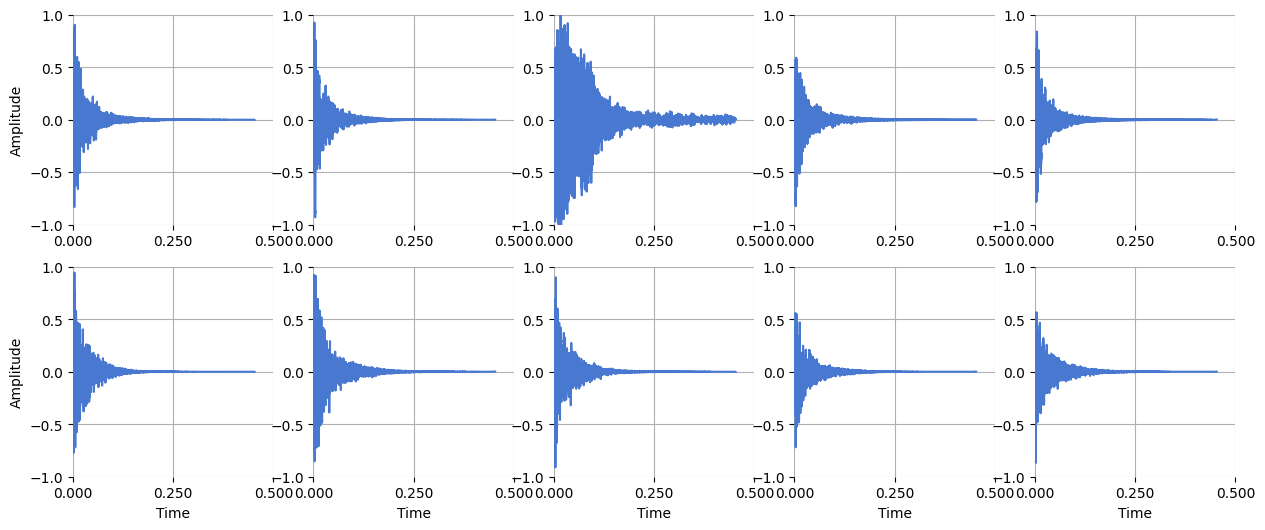

In [25]:
plt.figure(figsize=(15, 6))
for i, x in enumerate(snare_signals):
    plt.subplot(2, 5, i + 1)
    librosa.display.waveshow(x[:10000])

    # Y-axis label only on the first column
    if i == 0 or i == 5:
        plt.ylabel("Amplitude")

    # X-axis label only on the bottom row
    if i >= 5:
        plt.xlabel("Time")
    else:
        plt.xlabel("")

    plt.gca().set_xticks([0, 0.25, 0.5])
    plt.ylim(-1, 1)

# Constructing a Feature Vector

In [27]:
def extract_features(signal):
    return [
        #Zero crossing rate representshow often an audio waveform crosses center line 0.
        #Therefore, noisy or the sharp sound creates the high 0 crossing rate.
        librosa.feature.zero_crossing_rate(y=signal)[0, 0],
        #Center of the sound frequencies. 
        #Most of the energy is in the high frequency = spectral centroid is high.
        #Most of the energy is in the low frequency = spectral centroid is low.
        librosa.feature.spectral_centroid(y=signal)[0, 0],
    ]

In [28]:
kick_features = numpy.array([extract_features(x) for x in kick_signals])
snare_features = numpy.array([extract_features(x) for x in snare_signals])

Text(0, 0.5, 'Count')

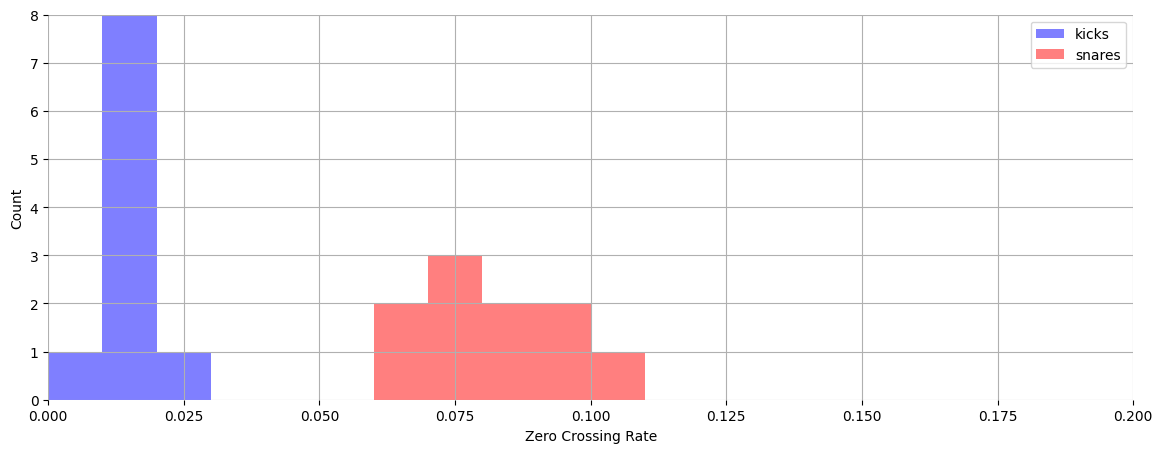

In [ ]:
plt.figure(figsize=(14, 5))
plt.hist(kick_features[:, 0], color="b", range=(0, 0.2), alpha=0.5, bins=20)
plt.hist(snare_features[:, 0], color="r", range=(0, 0.2), alpha=0.5, bins=20)
plt.legend(("kicks", "snares"))
plt.xlabel("Zero Crossing Rate")
plt.ylabel("Count")

# Since kick is the one that has the lower sound, it has the lower zero crossing rate compare to the snare which consider pretty high. 

Text(0, 0.5, 'Count')

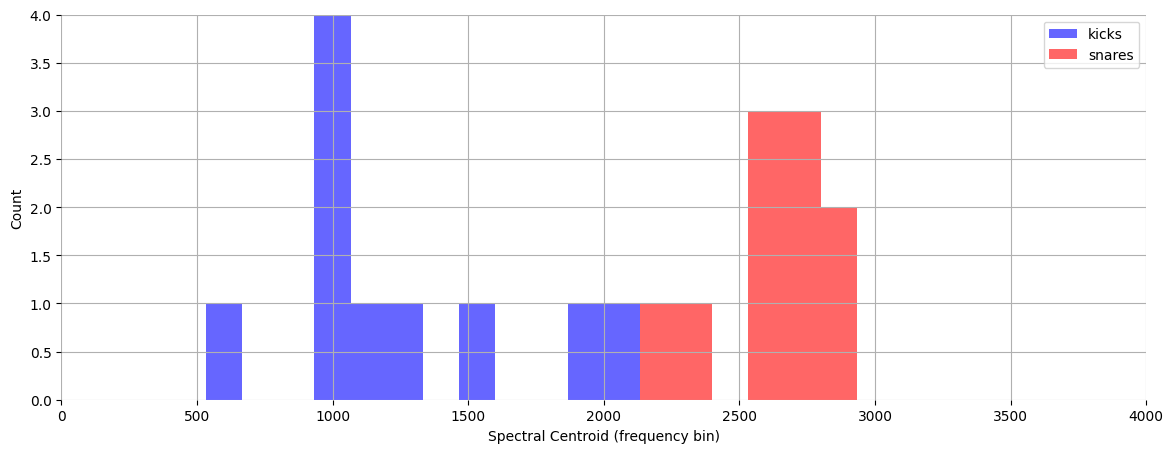

In [ ]:
plt.figure(figsize=(14, 5))
plt.hist(kick_features[:, 1], color="b", range=(0, 4000), bins=30, alpha=0.6)
plt.hist(snare_features[:, 1], color="r", range=(0, 4000), bins=30, alpha=0.6)
plt.legend(("kicks", "snares"))
plt.xlabel("Spectral Centroid (frequency bin)")
plt.ylabel("Count")

#Since kick has the low tone sound, it has higher Spectral Centroid.s